# Banking on Behaviour - Starter Notebook

This notebook shows you how to load the data and create a valid submission.

Feature engineering, model selection, and validation strategy are up to you.

**Target:** Predict `next_3m_txn_count` for each customer in Test.csv

**Metric:** RMSLE (Root Mean Squared Logarithmic Error)

## 1. Load Data

In [2]:
import pandas as pd
import numpy as np

# Core files
train = pd.read_csv('../data/raw/Train.csv')
test = pd.read_csv('../data/raw/Test.csv')


train.head()
train.shape

(8360, 2)

<Axes: >

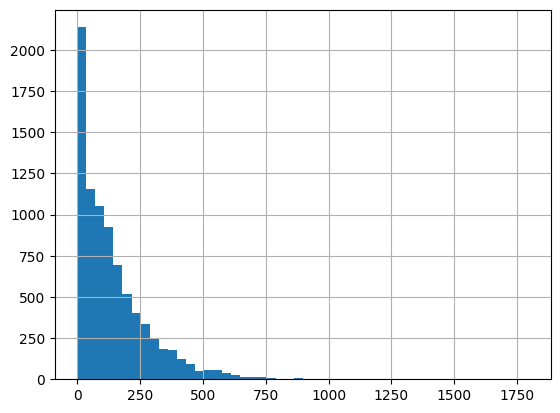

In [3]:
#Understanding the target
train['next_3m_txn_count'].describe()

#checking for missing values
train.isnull().sum() #no missing values

#analysing the skewness of the target variable
train['next_3m_txn_count'].hist(bins=50)

## 2. Explore the Feature Files

In [4]:
# Transaction history (18M rows - this may take a moment)
txn = pd.read_parquet('../data/raw/transactions_features.parquet')

#sampling the data just for analysing to understsandiut
txn_sample = txn.sample(200000, random_state=42)
txn_sample['UniqueID'].nunique() #how many unique customeers in transaction

#msut conbvert transactions → customer-level features
txn_sample.groupby('UniqueID').size().describe()


txn_sample.info()

<class 'pandas.core.frame.DataFrame'>
Index: 200000 entries, 1829124 to 16006956
Data columns (total 9 columns):
 #   Column                       Non-Null Count   Dtype         
---  ------                       --------------   -----         
 0   UniqueID                     200000 non-null  string        
 1   AccountID                    200000 non-null  string        
 2   TransactionDate              200000 non-null  datetime64[ns]
 3   TransactionAmount            200000 non-null  float64       
 4   TransactionTypeDescription   200000 non-null  object        
 5   TransactionBatchDescription  200000 non-null  object        
 6   StatementBalance             200000 non-null  float64       
 7   IsDebitCredit                200000 non-null  object        
 8   ReversalTypeDescription      200000 non-null  object        
dtypes: datetime64[ns](1), float64(2), object(4), string(2)
memory usage: 15.3+ MB


In [5]:
#Understanding money behaviour
#grup by customer, select tarnsaction amount and sum the money customer has transacted from Dec 2012 → Oct 2015
#then get summary fo money behaviour
txn_sample.groupby("UniqueID")["TransactionAmount"].sum().describe()

count    1.089200e+04
mean    -3.122280e+03
std      2.442992e+05
min     -3.069872e+06
25%     -3.551698e+04
50%     -1.329420e+03
75%      1.813861e+04
max      3.155528e+06
Name: TransactionAmount, dtype: float64

<Axes: >

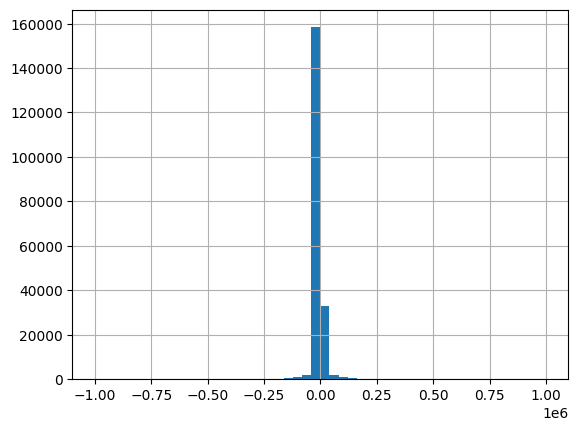

In [6]:
#looking at distribution of transaction amount
txn_sample['TransactionAmount'].hist(bins=50)

In [7]:
# Financial snapshots
# fin = pd.read_parquet('financials_features.parquet')
# print(f'Financials: {len(fin):,} rows, {fin.UniqueID.nunique():,} customers')
# print()
# print(fin.head())

In [8]:
# Demographics (one row per customer)
# demo = pd.read_parquet('demographics_clean.parquet')
# print(f'Demographics: {len(demo):,} rows')
# print()
# print(demo.head())

## 3. Your Work Goes Here

This is where you build your solution. Some things to think about:

- How will you aggregate 18M transaction rows into customer-level features?
- Which columns are most useful? Which ones need cleaning?
- How does the prediction window relate to the feature data?
- What modelling approach will you use?

## Stage 1: Use Transactions data only
- Learn behaviour
- Building basic model
- keep creating features and improving model


In [9]:
# Your feature engineering
# Building customer level features
customer_features = txn_sample.groupby("UniqueID").agg({
    "TransactionAmount":["count", "sum", "mean", "std"]}).reset_index()


#renaming
customer_features.columns = [
    "UniqueID",
    "txn_count",
    "txn_total_amount",
    "txn_avg_amount",
    "txn_std_amount"
]
customer_features.head()

#merging feature to tarin data
#this will be my modelling dataset
train_merged = train.merge(customer_features, on="UniqueID", how="left")
train_merged.head()

#handling some missing values
train_merged.isnull().sum()
train_merged = train_merged.fillna(0)



In [10]:
# Your model training
#building my first very basica model
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

x = train_merged[["txn_count", "txn_total_amount", "txn_avg_amount"]]
y = train_merged["next_3m_txn_count"]

X_train, X_val, y_train, y_val = train_test_split(x, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train,y_train)

# Your predictions
y_pred = model.predict(X_val)

#evaluate using RMSLE(the metric)
rmsle = np.sqrt(np.mean((np.log1p(y_pred) - np.log1p(y_val))**2))
rmsle



np.float64(0.7360026639127822)

In [11]:
train_merged.head()

,UniqueID,next_3m_txn_count,txn_count,txn_total_amount,txn_avg_amount,txn_std_amount
0,00093e2d-9e1e-4061-ad27-a79b8ff9e165,129,13.0,-39741.65,-3057.050000,8316.986884
1,0011d60f-a4e2-4333-81fc-2d557a82109b,16,1.0,-496.13,-496.130000,0.000000
2,0016f1e2-64c1-4c65-a668-1dc6bf3b5875,117,1.0,0.00,0.000000,0.000000
3,001aa3c5-632d-435e-a421-cc3615ccef4d,70,6.0,-1401.23,-233.538333,1698.406965
4,00298c6f-4f9d-4f28-b72c-ad0e56e9eb84,393,25.0,-4857.24,-194.289600,409.495654


#### Basic regression model evaluation(stage 1 of my model building)
- The RMSLE is weak. Which is expected.
- But I have built the baseline
- My model doesn't know:
    - When transactions happened (time)
    - Whether behaviour is increasing/decreasing
    - Consistency over time
    - Recency (recent activity vs old)

In [12]:
## New feature: How recent was last transaction
#get the most recent transation date per customer
# reset_index() converts the result into a proper DataFrame
last_txn = txn_sample.groupby('UniqueID')['TransactionDate'].max().reset_index()

#just going to remoe other columsn for clarity
last_txn.columns = ['UniqueID', 'last_txn_date']

# Get latest date in dataset (reference point)
max_date = txn_sample['TransactionDate'].max()

# Calculate inactivity (days since last transaction)
last_txn['days_since_last_txn'] = (max_date - last_txn['last_txn_date']).dt.days

#merge this into train  dataset
train_merged = train_merged.merge(last_txn[['UniqueID', 'days_since_last_txn']], on='UniqueID', how='left')

In [13]:
train_merged.head()
#fill missing values with na
train_merged = train_merged.fillna(999)

In [14]:
#retarin model with new featuyre
x = train_merged[["txn_count", "txn_total_amount", "txn_avg_amount", "days_since_last_txn"]]
y = train_merged["next_3m_txn_count"]

X_train, X_val, y_train, y_val = train_test_split(x, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train,y_train)

# Your predictions
y_pred = model.predict(X_val)

#evaluate using RMSLE(the metric)
rmsle = np.sqrt(np.mean((np.log1p(y_pred) - np.log1p(y_val))**2))
rmsle

np.float64(0.7272342911501767)

### "days_since_last_txn" feature insights
- The rmsle improved by ~0.009 when thsi feature was added.
- Therefore the feature is meaningfule, relevant and helping the model learn
- Therefore I just proved: Customers who transacted recently are more likely to transact again
- What behaviour am I still missing? Comsistency over time (how consistently they transact)



In [15]:
#extracting year-month from date
txn_sample['year_month'] = txn_sample['TransactionDate'].dt.to_period('M')
train_merged.head()

,UniqueID,next_3m_txn_count,txn_count,txn_total_amount,txn_avg_amount,txn_std_amount,days_since_last_txn
0,00093e2d-9e1e-4061-ad27-a79b8ff9e165,129,13.0,-39741.65,-3057.050000,8316.986884,47.0
1,0011d60f-a4e2-4333-81fc-2d557a82109b,16,1.0,-496.13,-496.130000,0.000000,37.0
2,0016f1e2-64c1-4c65-a668-1dc6bf3b5875,117,1.0,0.00,0.000000,0.000000,42.0
3,001aa3c5-632d-435e-a421-cc3615ccef4d,70,6.0,-1401.23,-233.538333,1698.406965,139.0
4,00298c6f-4f9d-4f28-b72c-ad0e56e9eb84,393,25.0,-4857.24,-194.289600,409.495654,36.0


In [16]:
# Extract month
txn_sample['year_month'] = txn_sample['TransactionDate'].dt.to_period('M')

# Count unique active months per customer
active_months = txn_sample.groupby('UniqueID')['year_month'].nunique().reset_index(name='active_months')

In [17]:
#merging to train
train_merged = train_merged.merge(active_months, on='UniqueID', how='left')
train_merged = train_merged.fillna(0)

In [18]:
train_merged.head()

,UniqueID,next_3m_txn_count,txn_count,txn_total_amount,txn_avg_amount,txn_std_amount,days_since_last_txn,active_months
0,00093e2d-9e1e-4061-ad27-a79b8ff9e165,129,13.0,-39741.65,-3057.050000,8316.986884,47.0,10.0
1,0011d60f-a4e2-4333-81fc-2d557a82109b,16,1.0,-496.13,-496.130000,0.000000,37.0,1.0
2,0016f1e2-64c1-4c65-a668-1dc6bf3b5875,117,1.0,0.00,0.000000,0.000000,42.0,1.0
3,001aa3c5-632d-435e-a421-cc3615ccef4d,70,6.0,-1401.23,-233.538333,1698.406965,139.0,5.0
4,00298c6f-4f9d-4f28-b72c-ad0e56e9eb84,393,25.0,-4857.24,-194.289600,409.495654,36.0,9.0


In [19]:
x = train_merged[
    ["txn_count", "txn_total_amount", "txn_avg_amount",
     "days_since_last_txn", "active_months"]
]
y = train_merged["next_3m_txn_count"]

X_train, X_val, y_train, y_val = train_test_split(x, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train,y_train)

# Your predictions
y_pred = model.predict(X_val)

#evaluate using RMSLE(the metric)
rmsle = np.sqrt(np.mean((np.log1p(y_pred) - np.log1p(y_val))**2))
rmsle

np.float64(0.7515281317384215)

### Changing the model

I built a baseline model using Linear Regression with features derived from transaction data.

Even after adding new features (active_months), the model performance (RMSLE) did not improve consistently and sometimes got worse.

**Now I am swicthing to a more powerful model**
Switch to:
**LightGBM (Gradient Boosting Model)**

In [20]:
#importing LightGBM model
from lightgbm import LGBMRegressor

#features
x = train_merged[
    ["txn_count", "txn_total_amount", "txn_avg_amount",
     "days_since_last_txn", "active_months"]
]

#target
y = train_merged["next_3m_txn_count"]
X_train, X_val, y_train, y_val = train_test_split(
    x, y,
    test_size=0.2,      # 20% for validation
    random_state=42     # ensures same split every time
)

#creating the model
# Create the model
model = LGBMRegressor(
    n_estimators=100,   # number of trees (more = more complex model)
    learning_rate=0.1,  # how fast the model learns
    random_state=42     # reproducibility
)
#training the model
model.fit(X_train, y_train)
#make predictions
y_pred = model.predict(X_val)
# Ensure no negative predictions (RMSLE cannot handle negatives)
y_pred = np.maximum(y_pred, 0)

# Calculate RMSLE
rmsle = np.sqrt(np.mean((np.log1p(y_pred) - np.log1p(y_val))**2))

print("LightGBM RMSLE:", rmsle)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000197 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 896
[LightGBM] [Info] Number of data points in the train set: 6688, number of used features: 5
[LightGBM] [Info] Start training from score 145.296202
LightGBM RMSLE: 0.7255356545655686


In [21]:
# Convert recency into a smoother signal
# WHY: Model learns better from scaled values

train_merged["recency_score"] = 1 / (train_merged["days_since_last_txn"] + 1)

In [27]:
x = train_merged[
    [
        "txn_count",
        "txn_total_amount",
        "txn_avg_amount",
        "txn_std_amount",
        "days_since_last_txn",
        "active_months",
        "recency_score"
        
    ]
]
#target
y = train_merged["next_3m_txn_count"]
X_train, X_val, y_train, y_val = train_test_split(
    x, y,
    test_size=0.2,      # 20% for validation
    random_state=42     # ensures same split every time
)
model = LGBMRegressor(
    n_estimators=200,
    learning_rate=0.05,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_val)
y_pred = np.maximum(y_pred, 0)

rmsle = np.sqrt(np.mean((np.log1p(y_pred) - np.log1p(y_val))**2))
print("New RMSLE:", rmsle)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000105 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1370
[LightGBM] [Info] Number of data points in the train set: 6688, number of used features: 7
[LightGBM] [Info] Start training from score 145.296202
New RMSLE: 0.7252075953834559


## 4. Create a Valid Submission

Your submission must match the format of SampleSubmission.csv exactly.

In [ ]:
submission = pd.read_csv('SampleSubmission.csv')

# Replace this with your actual predictions
submission['next_3m_txn_count'] = train['next_3m_txn_count'].mean()

submission.to_csv('submission.csv', index=False)
print(f'Submission saved: {len(submission)} rows')
print(submission.head())

## Local Scoring

You can score your submission locally using the included evaluate.py script:



Note: PublicReference.csv is only available if you have it for local testing. On Zindi, scoring is automatic.